In [13]:
import pandas as pd
import yaml
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

In [3]:
params = yaml.safe_load(open("../params.yaml", "r", encoding="utf-8"))
D, S, T = params["data"], params["split"], params["train"]
target = S["target"]

In [4]:
def load_xy(fp: str):
    df = pd.read_csv(fp)
    y = df[target]
    X = df.drop(columns=[target])
    return X, y

In [5]:
Xtr, ytr = load_xy(D["train"])
Xte, yte = load_xy(D["test"])

print(f"Train shape: {Xtr.shape}")
print(f"Test shape: {Xte.shape}")

Train shape: (1688, 19)
Test shape: (423, 19)


In [8]:
models = {
    "DecisionTree": DecisionTreeClassifier(
        max_depth=15,
        random_state=T["random_state"],
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=T["n_estimators"],
        max_depth=T["param_grid"]["max_depth"][1],
        random_state=T["random_state"],
        n_jobs=-1,
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=T["random_state"],
    ),
}

In [9]:
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    model.fit(Xtr, ytr)
    pte = model.predict(Xte)

    cv_scores = cross_val_score(model, Xtr, ytr, cv=5, scoring="f1_macro", n_jobs=-1)

    results[name] = {
        "test_accuracy": round(float(accuracy_score(yte, pte)), 4),
        "test_f1_macro": round(float(f1_score(yte, pte, average="macro")), 4),
        "test_precision_macro": round(
            float(precision_score(yte, pte, average="macro")), 4
        ),
        "test_recall_macro": round(float(recall_score(yte, pte, average="macro")), 4),
        "cv_f1_macro_mean": round(float(cv_scores.mean()), 4),
        "cv_f1_macro_std": round(float(cv_scores.std()), 4),
    }


Training DecisionTree...

Training RandomForest...

Training GradientBoosting...


In [10]:
results_df = pd.DataFrame(results).T.sort_values(by="test_f1_macro", ascending=False)
results_df

,test_accuracy,test_f1_macro,test_precision_macro,test_recall_macro,cv_f1_macro_mean,cv_f1_macro_std
GradientBoosting,0.9645,0.9633,0.9659,0.9628,0.9624,0.0090
DecisionTree,0.9220,0.9191,0.9216,0.9181,0.9112,0.0085
RandomForest,0.8700,0.8680,0.8730,0.8680,0.8652,0.0147


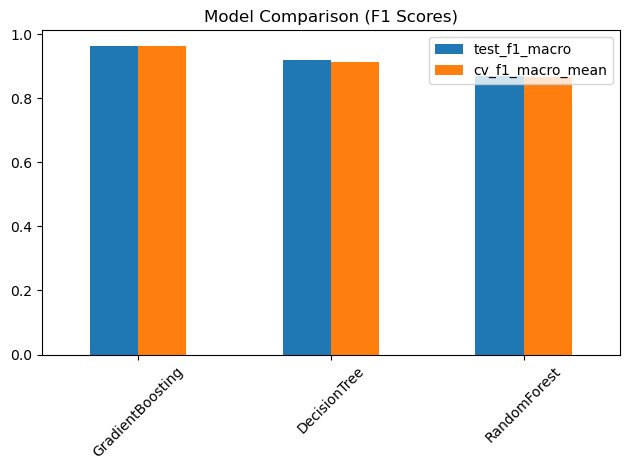

In [12]:
results_df[["test_f1_macro", "cv_f1_macro_mean"]].plot(kind="bar")
plt.title("Model Comparison (F1 Scores)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
param_grid = T["param_grid"]

base_clf = GradientBoostingClassifier(
    n_estimators=T["n_estimators"],
    random_state=T["random_state"],
)

grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(Xtr, ytr)

print("Best params:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'learning_rate': 0.05, 'max_depth': 5}
Best CV score: 0.9673235160176269


In [15]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values(by="mean_test_score", ascending=False)

results_df[["params", "mean_test_score", "std_test_score"]].head()

,params,mean_test_score,std_test_score
1,"{'learning_rate': 0.05, 'max_depth': 5}",0.967324,0.006985
7,"{'learning_rate': 0.2, 'max_depth': 5}",0.965429,0.005741
8,"{'learning_rate': 0.2, 'max_depth': 7}",0.964857,0.007372
5,"{'learning_rate': 0.1, 'max_depth': 7}",0.964839,0.009356
4,"{'learning_rate': 0.1, 'max_depth': 5}",0.963624,0.009563


In [18]:
importances = grid_search.best_estimator_.feature_importances_

fi_df = pd.DataFrame({"feature": Xtr.columns, "importance": importances}).sort_values(
    by="importance", ascending=False
)

fi_df.head(15)

,feature,importance
3,Weight,0.519383
2,Height,0.170395
6,FCVC,0.090893
0,Gender,0.072029
1,Age,0.038119
14,CALC,0.026573
10,CH2O,0.023178
8,CAEC,0.011506
7,NCP,0.011073
12,FAF,0.010820


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    grid_search.best_estimator_, Xte, yte, n_repeats=10, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame(
    {"feature": Xtr.columns, "importance": perm.importances_mean}
).sort_values(by="importance", ascending=False)

perm_df.head(15)

,feature,importance,importance_norm
3,Weight,0.519383,0.519383
2,Height,0.170395,0.170395
6,FCVC,0.090893,0.090893
0,Gender,0.072029,0.072029
1,Age,0.038119,0.038119
14,CALC,0.026573,0.026573
10,CH2O,0.023178,0.023178
8,CAEC,0.011506,0.011506
7,NCP,0.011073,0.011073
12,FAF,0.010820,0.010820
